# Analisis de canasta de precios
A partir de datos obtenidos de [SEPA](https://datos.produccion.gob.ar/dataset/sepa-precios) se busca ilustrar los resultados por provincia

In [1]:
# ============================================================
# CELDA 1 — Imports y carga de archivos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Subir los dos archivos a /content/ en Colab antes de correr esto
PATH_CANASTA = "/content/canasta_por_provincia.xlsx"
PATH_RESUMEN = "/content/productos_unicos_resumen.xlsx"

# --- Cargar canasta ---
ranking          = pd.read_excel(PATH_CANASTA, sheet_name='ranking_provincias')
canasta_total    = pd.read_excel(PATH_CANASTA, sheet_name='canasta_total')
precios_pivot    = pd.read_excel(PATH_CANASTA, sheet_name='precios_por_provincia')
precios_long     = pd.read_excel(PATH_CANASTA, sheet_name='detalle_largo')
def_canasta      = pd.read_excel(PATH_CANASTA, sheet_name='definicion_canasta')

# --- Cargar resumen ---
productos_unicos = pd.read_excel(PATH_RESUMEN, sheet_name='productos_unicos')
cob_provincia    = pd.read_excel(PATH_RESUMEN, sheet_name='cobertura_provincia')
cob_cadena       = pd.read_excel(PATH_RESUMEN, sheet_name='cobertura_cadena')
matriz_cad_prov  = pd.read_excel(PATH_RESUMEN, sheet_name='matriz_cadena_x_provincia')
metadata         = pd.read_excel(PATH_RESUMEN, sheet_name='metadata')

# Configuración de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13

print("✅ Archivos cargados")
print(f"  - Canasta: {len(def_canasta)} productos, {len(ranking)} provincias")
print(f"  - Resumen: {len(productos_unicos):,} productos únicos")
print(f"  - Fecha del relevamiento: {metadata.set_index('campo').loc['fecha_relevamiento','valor']}")

✅ Archivos cargados
  - Canasta: 30 productos, 24 provincias
  - Resumen: 85,911 productos únicos
  - Fecha del relevamiento: 2026-04-26


## Composicion de la siguiente manera:

In [2]:
# ============================================================
# CELDA 2 — Composición de la canasta (para la metodología)
# ============================================================
# Cruzamos la definición de la canasta con la info de productos_unicos
# para tener marca, descripción completa, presentación y precio nacional.

comp = def_canasta.merge(
    productos_unicos[['id_producto','descripcion','marca',
                      'cantidad_presentacion','unidad_presentacion',
                      'n_cadenas','n_provincias','precio_promedio']],
    on='id_producto', how='left'
)

# Subtotal mensual estimado a precio nacional
comp['subtotal_mensual'] = (comp['cantidad_mensual'] * comp['precio_promedio']).round(2)

# Ordenar por categoría y nombre
orden_cat = ['Lácteos','Almacén','Bebidas','Limpieza','Higiene','Snacks']
comp['categoria'] = pd.Categorical(comp['categoria'], categories=orden_cat, ordered=True)
comp = comp.sort_values(['categoria','producto']).reset_index(drop=True)

# Vista resumida ordenada por categoría
print("="*100)
print("COMPOSICIÓN DE LA CANASTA")
print("="*100)

for cat in orden_cat:
    sub = comp[comp['categoria']==cat]
    if len(sub) == 0:
        continue
    print(f"\n--- {cat.upper()} ({len(sub)} productos) ---")
    for _, r in sub.iterrows():
        print(f"  EAN {r['id_producto']:<14}  {r['producto']:<30}  "
              f"{r['marca']:<20}  cant/mes: {r['cantidad_mensual']:>2}  "
              f"precio: ${r['precio_promedio']:>8,.0f}")

print("\n" + "="*100)
print(f"TOTAL DE LA CANASTA (a precios promedio nacionales): "
      f"${comp['subtotal_mensual'].sum():,.0f}")
print("="*100)

# Mostrar también como DataFrame (para verlo bonito en Colab)
comp[['id_producto','producto','marca','descripcion',
      'cantidad_presentacion','unidad_presentacion',
      'cantidad_mensual','categoria','precio_promedio',
      'n_cadenas','n_provincias','subtotal_mensual']]

COMPOSICIÓN DE LA CANASTA

--- LÁCTEOS (5 productos) ---
  EAN 7791337007253   Cindor 1L                       CINDOR                cant/mes:  4  precio: $   7,017
  EAN 7790742363008   Leche entera 1L                 LA SERENISIMA         cant/mes: 20  precio: $   2,630
  EAN 7793940052002   Manteca 100g                    LA SERENISIMA         cant/mes:  2  precio: $   2,614
  EAN 7791337061361   Queso Casancrem 290g            CASANCREM             cant/mes:  2  precio: $   5,243
  EAN 7791337007628   Yogur 190g                      YOGURISIMO            cant/mes:  8  precio: $   2,829

--- ALMACÉN (8 productos) ---
  EAN 7790272001029   Aceite girasol 1,5L             NATURA                cant/mes:  2  precio: $   6,587
  EAN 7790070433114   Arroz 500g                      GALLO ORO             cant/mes:  2  precio: $   1,354
  EAN 7790550000157   Café 250g                       LA PLANTA D/CAF       cant/mes:  1  precio: $   7,317
  EAN 7790040143234   Chocolinas 250g           

,id_producto,producto,marca,descripcion,cantidad_presentacion,unidad_presentacion,cantidad_mensual,categoria,precio_promedio,n_cadenas,n_provincias,subtotal_mensual
0,7791337007253,Cindor 1L,CINDOR,LECHE CHOCOLATADA PURO CACAO CINDOR TTB 1 LTR,1.0,ltr,4,Lácteos,7016.76,21,24,28067.04
1,7790742363008,Leche entera 1L,LA SERENISIMA,LECHE LV.ENTERA UAT CLASICA 3% LA SERENISIMA ...,1.0,ltr,20,Lácteos,2630.39,17,24,52607.80
2,7793940052002,Manteca 100g,LA SERENISIMA,MANTECA LA SERENISIMA PAN 100 GRM,100.0,grm,2,Lácteos,2614.20,18,24,5228.40
3,7791337061361,Queso Casancrem 290g,CASANCREM,QUESO CREMA CLÁSICO CASANCREM POT 290 GRM,290.0,grm,2,Lácteos,5243.47,17,24,10486.94
4,7791337007628,Yogur 190g,YOGURISIMO,YOGUR.ENT.FIRME SAB.VAINILLA YOGURISIMO POT 19...,190.0,grm,8,Lácteos,2829.00,18,24,22632.00
5,7790272001029,"Aceite girasol 1,5L",NATURA,"ACEITE GIRASOL NATURA BOT 1,5 LTR",1.5,ltr,2,Almacén,6586.88,18,24,13173.76
6,7790070433114,Arroz 500g,GALLO ORO,ARROZ PARBOIL SELECCIÓN GALLO ORO PAQ 500 GRM,500.0,grm,2,Almacén,1353.57,17,24,2707.14
7,7790550000157,Café 250g,LA PLANTA D/CAF,CAFE MOLIDO LA PLANTA D/CAFÉ. PAQ 250 GRM,250.0,grm,1,Almacén,7317.34,18,24,7317.34
8,7790040143234,Chocolinas 250g,CHOCOLINAS,GALLETITAS DUL.SAB.CHOCOLATE CHOCOLINAS PAQ 25...,250.0,grm,4,Almacén,2448.47,17,24,9793.88
9,7790070320285,Fideos 500g,FAVORITA,FIDEOS LARGOS FAVORITA SECOS PAQ 500 GRM,500.0,grm,4,Almacén,989.65,19,24,3958.60


In [3]:
# ============================================================
# CELDA 3 — Resumen agregado por categoría (para la metodología)
# ============================================================
resumen_cat = (comp.groupby('categoria', observed=True)
               .agg(productos=('id_producto','count'),
                    items_mensuales=('cantidad_mensual','sum'),
                    subtotal=('subtotal_mensual','sum'))
               .reset_index())
resumen_cat['peso_%'] = (resumen_cat['subtotal'] / resumen_cat['subtotal'].sum() * 100).round(1)

print("=== PESO DE CADA CATEGORÍA EN LA CANASTA ===")
print(resumen_cat.to_string(index=False))

=== PESO DE CADA CATEGORÍA EN LA CANASTA ===
categoria  productos  items_mensuales  subtotal  peso_%
  Lácteos          5               36 119022.18    36.3
  Almacén          8               18  46988.34    14.3
  Bebidas          5               28  82672.36    25.2
 Limpieza          3                6  12458.10     3.8
  Higiene          7               13  58505.94    17.9
   Snacks          2                4   7857.74     2.4


## Ranking por provincia

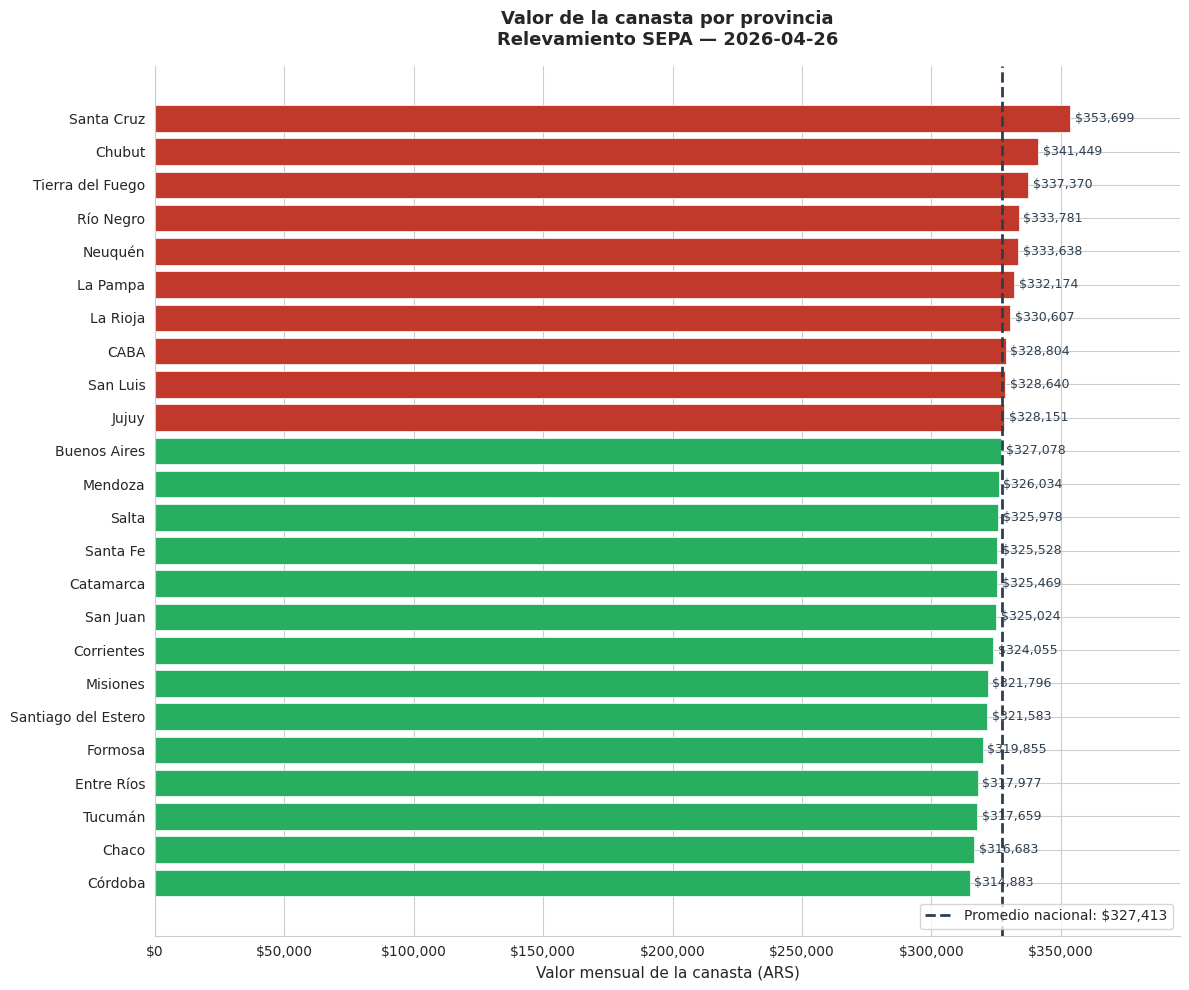


Promedio nacional: $327,413
Provincia más cara:  Santa Cruz           $353,699 (+8.0% vs promedio)
Provincia más barata: Córdoba              $314,883 (-3.8% vs promedio)


In [12]:
# ============================================================
# CELDA 4 — Ranking de provincias con promedio nacional
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Ordenar de menor a mayor para que el ranking quede de arriba (caro) a abajo (barato)
# Usamos la canasta completa imputada (la del ranking)
df_plot = ranking.sort_values('canasta_completa_imputada', ascending=True).reset_index(drop=True)

promedio_nacional = df_plot['canasta_completa_imputada'].mean()

# Colores: provincias por encima del promedio en rojo suave, por debajo en verde suave
colores = ['#c0392b' if v > promedio_nacional else '#27ae60'
           for v in df_plot['canasta_completa_imputada']]

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(df_plot['provincia'],
               df_plot['canasta_completa_imputada'],
               color=colores, edgecolor='white', linewidth=0.5)

# Línea de promedio nacional
ax.axvline(promedio_nacional, color='#2c3e50', linestyle='--', linewidth=2,
           label=f'Promedio nacional: ${promedio_nacional:,.0f}', zorder=3)

# Etiquetas con el valor al final de cada barra
max_val = df_plot['canasta_completa_imputada'].max()
for bar, valor in zip(bars, df_plot['canasta_completa_imputada']):
    ax.text(bar.get_width() + max_val*0.005,
            bar.get_y() + bar.get_height()/2,
            f'${valor:,.0f}',
            va='center', ha='left', fontsize=9, color='#2c3e50')

# Estética
ax.set_xlabel('Valor mensual de la canasta (ARS)', fontsize=11)
ax.set_ylabel('')
ax.set_title('Valor de la canasta por provincia\n'
             f'Relevamiento SEPA — {metadata.set_index("campo").loc["fecha_relevamiento","valor"]}',
             fontsize=13, fontweight='bold', pad=15)

# Formato del eje X con separador de miles
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, max_val * 1.12)  # Margen para que entren las etiquetas

# Leyenda de la línea de promedio
ax.legend(loc='lower right', frameon=True, fontsize=10)

# Quitar bordes innecesarios
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('/content/ranking_canasta_provincias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPromedio nacional: ${promedio_nacional:,.0f}")
print(f"Provincia más cara:  {df_plot.iloc[-1]['provincia']:<20} "
      f"${df_plot.iloc[-1]['canasta_completa_imputada']:,.0f} "
      f"({(df_plot.iloc[-1]['canasta_completa_imputada']/promedio_nacional-1)*100:+.1f}% vs promedio)")
print(f"Provincia más barata: {df_plot.iloc[0]['provincia']:<20} "
      f"${df_plot.iloc[0]['canasta_completa_imputada']:,.0f} "
      f"({(df_plot.iloc[0]['canasta_completa_imputada']/promedio_nacional-1)*100:+.1f}% vs promedio)")

In [5]:
# ============================================================
# CELDA — Explorar ar.json
# ============================================================
import json
from pathlib import Path

PATH_GEO = "/content/ar.json"

# 1) Tamaño y tipo de archivo
size_mb = Path(PATH_GEO).stat().st_size / 1024 / 1024
print(f"Tamaño del archivo: {size_mb:.2f} MB\n")

with open(PATH_GEO, 'r', encoding='utf-8') as f:
    geo = json.load(f)

# 2) Estructura general
print(f"Tipo raíz: {type(geo).__name__}")
if isinstance(geo, dict):
    print(f"Claves principales: {list(geo.keys())}")
    if 'type' in geo:
        print(f"GeoJSON type: {geo['type']}")
    if 'features' in geo:
        print(f"Cantidad de features: {len(geo['features'])}")
print()

# 3) Si es un GeoJSON estándar (FeatureCollection), explorar el primer feature
if isinstance(geo, dict) and geo.get('type') == 'FeatureCollection':
    f0 = geo['features'][0]
    print("=== Estructura del primer feature ===")
    print(f"Tipo de geometría: {f0.get('geometry', {}).get('type')}")
    print(f"Propiedades disponibles: {list(f0.get('properties', {}).keys())}")
    print(f"\nValores del primer feature:")
    for k, v in f0.get('properties', {}).items():
        print(f"  {k}: {v}")

    # 4) Listar todos los nombres de provincias usando cada clave candidata
    props_keys = list(f0['properties'].keys())
    print(f"\n=== Valores únicos por cada propiedad ({len(geo['features'])} features) ===")
    for k in props_keys:
        valores = sorted({str(f['properties'].get(k)) for f in geo['features']})
        # Solo mostramos si parecen nombres de provincias (cantidad razonable)
        if 5 <= len(valores) <= 30:
            print(f"\n→ Propiedad '{k}' ({len(valores)} valores únicos):")
            for v in valores:
                print(f"    {v}")

Tamaño del archivo: 1.02 MB

Tipo raíz: dict
Claves principales: ['type', 'features']
GeoJSON type: FeatureCollection
Cantidad de features: 24

=== Estructura del primer feature ===
Tipo de geometría: Polygon
Propiedades disponibles: ['source', 'id', 'name']

Valores del primer feature:
  source: https://simplemaps.com
  id: ARE
  name: Entre Ríos

=== Valores únicos por cada propiedad (24 features) ===

→ Propiedad 'id' (24 valores únicos):
    ARA
    ARB
    ARC
    ARD
    ARE
    ARF
    ARG
    ARH
    ARJ
    ARK
    ARL
    ARM
    ARN
    ARP
    ARQ
    ARR
    ARS
    ART
    ARU
    ARV
    ARW
    ARX
    ARY
    ARZ

→ Propiedad 'name' (24 valores únicos):
    Buenos Aires
    Catamarca
    Chaco
    Chubut
    Ciudad de Buenos Aires
    Corrientes
    Córdoba
    Entre Ríos
    Formosa
    Jujuy
    La Pampa
    La Rioja
    Mendoza
    Misiones
    Neuquén
    Río Negro
    Salta
    San Juan
    San Luis
    Santa Cruz
    Santa Fe
    Santiago del Estero
    Tierra de

In [6]:
# ============================================================
# CELDA — Comparar nombres del GeoJSON contra los del ranking
# ============================================================
# Una vez identificada la propiedad correcta del paso anterior,
# ajustá PROP_NOMBRE al nombre real de la propiedad
PROP_NOMBRE = 'name'  # <-- CAMBIAR según lo que viste arriba (puede ser 'name', 'nombre', 'NAME_1', 'provincia', etc.)

nombres_geo = sorted({f['properties'].get(PROP_NOMBRE) for f in geo['features']})
nombres_ranking = sorted(ranking['provincia'].unique())

print(f"Provincias en GeoJSON ({len(nombres_geo)}):")
print(nombres_geo)
print(f"\nProvincias en ranking ({len(nombres_ranking)}):")
print(nombres_ranking)

# Diferencias
en_geo_no_ranking = set(nombres_geo) - set(nombres_ranking)
en_ranking_no_geo = set(nombres_ranking) - set(nombres_geo)

print(f"\n⚠️ En GeoJSON pero no en ranking: {en_geo_no_ranking}")
print(f"⚠️ En ranking pero no en GeoJSON: {en_ranking_no_geo}")

if not en_geo_no_ranking and not en_ranking_no_geo:
    print("\n✅ Los nombres coinciden perfectamente — listo para el mapa")
else:
    print("\n⚠️ Hay diferencias — vamos a necesitar un diccionario de mapeo antes del mapa")

Provincias en GeoJSON (24):
['Buenos Aires', 'Catamarca', 'Chaco', 'Chubut', 'Ciudad de Buenos Aires', 'Corrientes', 'Córdoba', 'Entre Ríos', 'Formosa', 'Jujuy', 'La Pampa', 'La Rioja', 'Mendoza', 'Misiones', 'Neuquén', 'Río Negro', 'Salta', 'San Juan', 'San Luis', 'Santa Cruz', 'Santa Fe', 'Santiago del Estero', 'Tierra del Fuego', 'Tucumán']

Provincias en ranking (24):
['Buenos Aires', 'CABA', 'Catamarca', 'Chaco', 'Chubut', 'Corrientes', 'Córdoba', 'Entre Ríos', 'Formosa', 'Jujuy', 'La Pampa', 'La Rioja', 'Mendoza', 'Misiones', 'Neuquén', 'Río Negro', 'Salta', 'San Juan', 'San Luis', 'Santa Cruz', 'Santa Fe', 'Santiago del Estero', 'Tierra del Fuego', 'Tucumán']

⚠️ En GeoJSON pero no en ranking: {'Ciudad de Buenos Aires'}
⚠️ En ranking pero no en GeoJSON: {'CABA'}

⚠️ Hay diferencias — vamos a necesitar un diccionario de mapeo antes del mapa


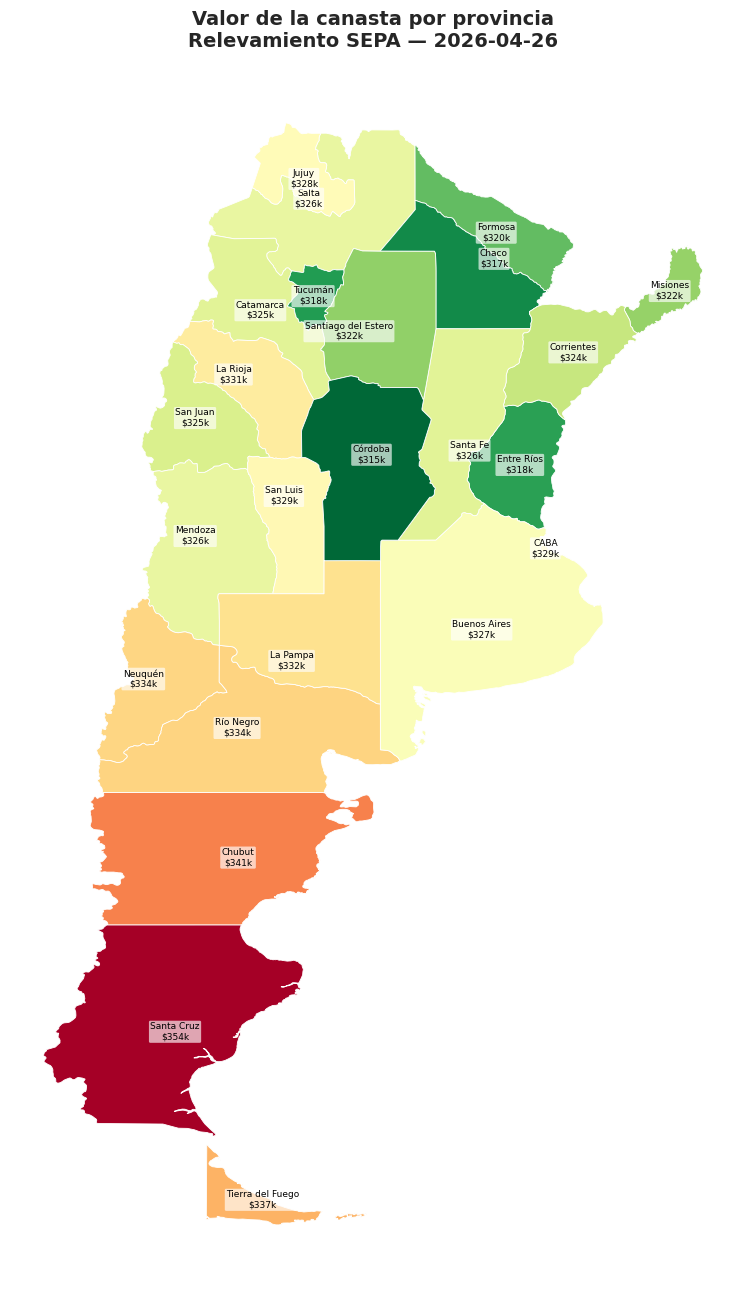


Promedio nacional: $327,413
Más cara:  Santa Cruz                $353,699
Más barata: Córdoba                   $314,883


In [13]:
# ============================================================
# CELDA — Mapa coroplético de la canasta por provincia
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np

# 1) Diccionario de equivalencias (ranking -> GeoJSON)
EQUIV = {
    'CABA': 'Ciudad de Buenos Aires',
}

# 2) Crear DataFrame con nombre normalizado al estándar del GeoJSON
df_mapa = ranking.copy()
df_mapa['provincia_geo'] = df_mapa['provincia'].replace(EQUIV)

# 3) Diccionario para lookup rápido valor por provincia
valor_por_prov = dict(zip(df_mapa['provincia_geo'], df_mapa['canasta_completa_imputada']))
promedio_nacional = df_mapa['canasta_completa_imputada'].mean()

# 4) Escala de color: divergente centrada en el promedio nacional
vmin = df_mapa['canasta_completa_imputada'].min()
vmax = df_mapa['canasta_completa_imputada'].max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=promedio_nacional, vmax=vmax)
cmap = plt.cm.RdYlGn_r  # verde = barato, rojo = caro

# 5) Dibujar
fig, ax = plt.subplots(figsize=(10, 13))

for feature in geo['features']:
    nombre = feature['properties']['name']
    valor = valor_por_prov.get(nombre)
    color = cmap(norm(valor)) if valor is not None else '#dddddd'

    geom = feature['geometry']
    coords_list = geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]

    for polygon in coords_list:
        # polygon[0] es el anillo exterior; ignoramos hoyos para simplicidad
        ring = np.array(polygon[0])
        ax.fill(ring[:, 0], ring[:, 1], color=color, edgecolor='white', linewidth=0.6)

# 6) Etiquetas: nombre + valor en el centroide aproximado de cada provincia
for feature in geo['features']:
    nombre = feature['properties']['name']
    valor = valor_por_prov.get(nombre)
    if valor is None:
        continue

    geom = feature['geometry']
    coords_list = geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]
    # Tomamos el polígono más grande (descarta islas pequeñas)
    biggest = max(coords_list, key=lambda p: len(p[0]))
    ring = np.array(biggest[0])
    cx, cy = ring[:, 0].mean(), ring[:, 1].mean()

    label = f"{nombre.replace('Ciudad de Buenos Aires','CABA')}\n${valor/1000:.0f}k"
    ax.annotate(label, xy=(cx, cy), ha='center', va='center',
                fontsize=6.5, color='black',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          edgecolor='none', alpha=0.65))

# 7) Estética del eje
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Valor de la canasta por provincia\n'
             f'Relevamiento SEPA — {metadata.set_index("campo").loc["fecha_relevamiento","valor"]}',
             fontsize=14, fontweight='bold', pad=15)



plt.tight_layout()
plt.savefig('/content/mapa_canasta_provincias.png', dpi=180, bbox_inches='tight')
plt.show()

# 9) Resumen impreso
print(f"\nPromedio nacional: ${promedio_nacional:,.0f}")
print(f"Más cara:  {df_mapa.iloc[-1]['provincia']:<25} ${df_mapa.iloc[-1]['canasta_completa_imputada']:,.0f}")
print(f"Más barata: {df_mapa.iloc[0]['provincia']:<25} ${df_mapa.iloc[0]['canasta_completa_imputada']:,.0f}")